# Assignment 1 2AMM10 2025-2026

## Group: YapGPT
### Member 1: Nicole Ganin
### Member 2: Sybren Postma
### Member 3: Vivan Victoria

## Task 1 

Dataset and visualization

In [2]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


CACHE_FILE = Path.home() / ".apple_dataset_path.txt"

def get_dataset_path():
    # If we've already stored it locally, reuse it
    if CACHE_FILE.exists():
        return Path(CACHE_FILE.read_text().strip())

    # Otherwise download
    path = kagglehub.dataset_download("moltean/fruits")

    # Save for next time
    CACHE_FILE.write_text(str(path))

    return Path(path)


class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = get_dataset_path()
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

In [4]:
from torchvision import transforms

In [5]:
transform = transforms.Compose([transforms.Resize((100,100)), transforms.ToTensor(),])
train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# your code here


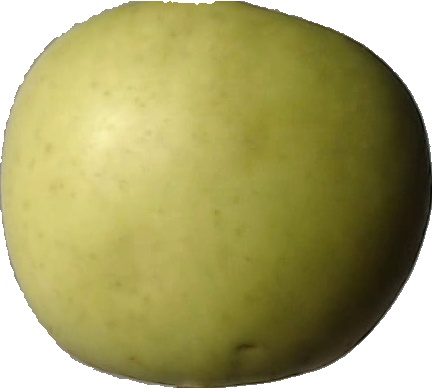

In [26]:
dataset[1000][0]

In [6]:
train_data[1][0].permute(1,2,0)

tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        ...,

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])

An appropriate neural network to learn embeddings from this dataset, could be Convolutional Neural Network

### 2
Triplet Loss
Loss = max(0, d(a,p) − d(a,n) + margin)

where
a = anchor
p = same item
n = different item

In [29]:
from torchvision import transforms
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [31]:
import random
from collections import defaultdict

class TripletAppleDataset(Dataset):
    def __init__(self, base_dataset):
        self.dataset = base_dataset

        self.label_to_indices = defaultdict(list)

        for idx in range(len(base_dataset)):
            _, label = base_dataset[idx]
            self.label_to_indices[label].append(idx)

        self.labels = list(self.label_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_label = self.dataset[idx]

        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(self.label_to_indices[anchor_label])

        negative_label = random.choice(self.labels)
        while negative_label == anchor_label:
            negative_label = random.choice(self.labels)

        negative_idx = random.choice(self.label_to_indices[negative_label])

        positive_img, _ = self.dataset[positive_idx]
        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img

In [37]:
triplet_train = TripletAppleDataset(train_data)

train_loader = DataLoader(
    triplet_train,
    batch_size=64,
    shuffle=True
)

### 3
Model implementation and training

In [39]:
class EmbeddingNet(nn.Module): # ChatGPT suggested 3 layers
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*12*12,256),
            nn.ReLU(),
            nn.Linear(256,embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        x = F.normalize(x,p=2,dim=1)
        return x

In [41]:
triplet_loss = nn.TripletMarginLoss(margin=1.0)

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EmbeddingNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for anchor, positive, negative in train_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        anchor_emb = model(anchor)
        positive_emb = model(positive)
        negative_emb = model(negative)

        loss = triplet_loss(anchor_emb, positive_emb, negative_emb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss/len(train_loader):.4f}")

Epoch 1: 0.1854
Epoch 2: 0.0569
Epoch 3: 0.0261
Epoch 4: 0.0166
Epoch 5: 0.0120
Epoch 6: 0.0067
Epoch 7: 0.0031
Epoch 8: 0.0020
Epoch 9: 0.0020
Epoch 10: 0.0008
Epoch 11: 0.0016
Epoch 12: 0.0012
Epoch 13: 0.0025
Epoch 14: 0.0009
Epoch 15: 0.0002


In [44]:
def extract_embeddings(dataset, model):
    loader = DataLoader(dataset, batch_size=64)

    embeddings = []
    labels = []

    model.eval()

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)

            emb = model(imgs)

            embeddings.append(emb.cpu())
            labels.extend(lbls)

    embeddings = torch.cat(embeddings)

    return embeddings.numpy(), np.array(labels)

In [45]:
train_embeddings, train_labels = extract_embeddings(train_data, model)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(train_embeddings, train_labels)

KNeighborsClassifier(n_neighbors=1)

In [46]:
test_embeddings, test_labels = extract_embeddings(test_data, model)

preds = knn.predict(test_embeddings)

acc = accuracy_score(test_labels, preds)
print("Seen item accuracy:", acc)

Seen item accuracy: 0.9479843953185956


In [47]:
support_embeddings, support_labels = extract_embeddings(support_new_data, model)

knn_new = KNeighborsClassifier(n_neighbors=1)
knn_new.fit(support_embeddings, support_labels)

new_test_embeddings, new_test_labels = extract_embeddings(test_new_data, model)

new_preds = knn_new.predict(new_test_embeddings)

new_acc = accuracy_score(new_test_labels, new_preds)
print("Unseen item accuracy:", new_acc)

Unseen item accuracy: 0.9039692701664532


## Task 2

In [ ]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)
 
        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [ ]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here

## Task 3

In [ ]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

## Task 4

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
